In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r"C:\Users\Abcom\Desktop\mlops_project\Data\archive\creditcard.csv")

In [ ]:
skew(-1.359807) -> skewed value

skewed value > 5

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### Note: Imbalanced Dataset
#### If we train a model, Model can '0' for everything.

In [ ]:
492/284315*100

0.17304750013189596

##### TO SOlVE Imbalanced Dataset issue

 - Resampling Technique -  Oversampling

##### Explore the Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Checking the Null Values


df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
df.isnull().any().sum()

np.int64(0)

In [ ]:
# Checking Duplicates in the Dataset


df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [ ]:
# Removing the Duplicate rows


df.drop_duplicates(inplace=True)

In [ ]:
# Validating if Duplicate rows are found.

df[df.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
timeAnalysis = df[['Time','Amount','Class']].copy()

In [ ]:
timeAnalysis.describe()

,Time,Amount,Class
count,283726.000000,283726.000000,283726.000000
mean,94811.077600,88.472687,0.001667
std,47481.047891,250.399437,0.040796
min,0.000000,0.000000,0.000000
25%,54204.750000,5.600000,0.000000
50%,84692.500000,22.000000,0.000000
75%,139298.000000,77.510000,0.000000
max,172792.000000,25691.160000,1.000000


In [ ]:
import datetime
datetime.datetime.fromtimestamp(172792.000000)

datetime.datetime(1970, 1, 3, 5, 29, 52)

In [ ]:
# Time conversion function
def convert_to_time(seconds):
    return datetime.datetime.fromtimestamp(seconds)

In [ ]:
timeAnalysis['datetime'] = timeAnalysis.Time.apply(convert_to_time)

In [ ]:
timeAnalysis

,Time,Amount,Class,datetime
0,0.0,149.62,0,1970-01-01 05:30:00
1,0.0,2.69,0,1970-01-01 05:30:00
2,1.0,378.66,0,1970-01-01 05:30:01
3,1.0,123.50,0,1970-01-01 05:30:01
4,2.0,69.99,0,1970-01-01 05:30:02
...,...,...,...,...
284802,172786.0,0.77,0,1970-01-03 05:29:46
284803,172787.0,24.79,0,1970-01-03 05:29:47
284804,172788.0,67.88,0,1970-01-03 05:29:48
284805,172788.0,10.00,0,1970-01-03 05:29:48


In [ ]:
timeAnalysis.datetime

0        1970-01-01 05:30:00
1        1970-01-01 05:30:00
2        1970-01-01 05:30:01
3        1970-01-01 05:30:01
4        1970-01-01 05:30:02
                 ...        
284802   1970-01-03 05:29:46
284803   1970-01-03 05:29:47
284804   1970-01-03 05:29:48
284805   1970-01-03 05:29:48
284806   1970-01-03 05:29:52
Name: datetime, Length: 283726, dtype: datetime64[ns]

In [ ]:
timeAnalysis.datetime.dt.date

0         1970-01-01
1         1970-01-01
2         1970-01-01
3         1970-01-01
4         1970-01-01
             ...    
284802    1970-01-03
284803    1970-01-03
284804    1970-01-03
284805    1970-01-03
284806    1970-01-03
Name: datetime, Length: 283726, dtype: object

In [ ]:
start_datetime = timeAnalysis.datetime.min()
start_datetime

Timestamp('1970-01-01 05:30:00')

In [ ]:
end_datetime = timeAnalysis.datetime.max()

In [ ]:
print(f"Start Date and Time: {start_datetime}")
print(f"End Date and Time: {end_datetime}")


Start Date and Time: 1970-01-01 05:30:00
End Date and Time: 1970-01-03 05:29:52


In [ ]:
start_datetime - end_datetime

Timedelta('-2 days +00:00:08')

In [ ]:
# Since it is 2 days of Dataset (48 hours)
# We can plot using hours 

timeAnalysis['hour_of_the_day'] = timeAnalysis.datetime.dt.hour

In [ ]:
# Applying groupby function based on the Class Column & Hours

timeAnalysisgroupby = timeAnalysis.groupby(['Class','hour_of_the_day'])['Amount'].count()
timeAnalysisgroupby

Class  hour_of_the_day
0      0                  16686
       1                  15920
       2                  17390
       3                  17237
       4                  12828
       5                   9403
       6                   5690
       7                   3045
       8                   4174
       9                   2499
       10                  2075
       11                  3452
       12                  5492
       13                  8542
       14                 13314
       15                 16323
       16                 16712
       17                 16389
       18                 14966
       19                 15801
       20                 16710
       21                 16039
       22                 16569
       23                 15997
1      0                     24
       1                     15
       2                     25
       3                      9
       4                     10
       5                     14
       6         

In [ ]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'No. of Credit Card Transactions Per Hour'}, xlabel='hour_of_the_day'>

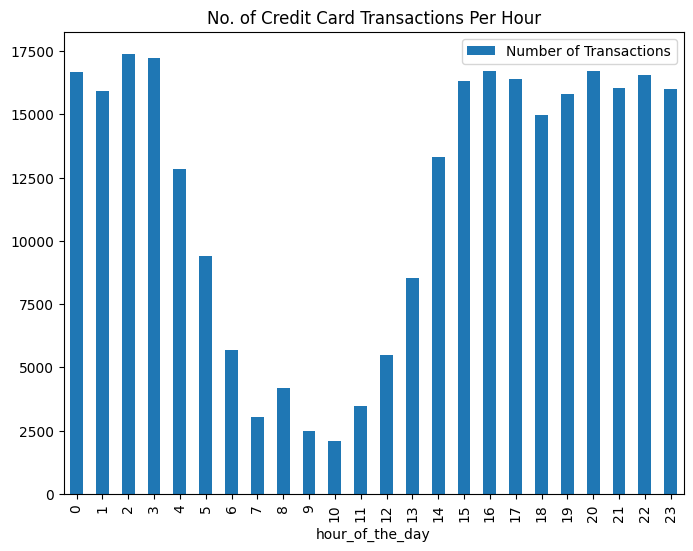

In [ ]:
plt.figure(figsize=(8,6))

# Transaction in hours
transactions = timeAnalysisgroupby[0].copy()

# Count of the Transactions
transactions.name = 'Number of Transactions'

# Plotting based on Transactions based on Hours
transactions.plot.bar(title="No. of Credit Card Transactions Per Hour", legend=True)

<Axes: title={'center': 'No. of Credit Card Transactions Per Hour'}, xlabel='hour_of_the_day'>

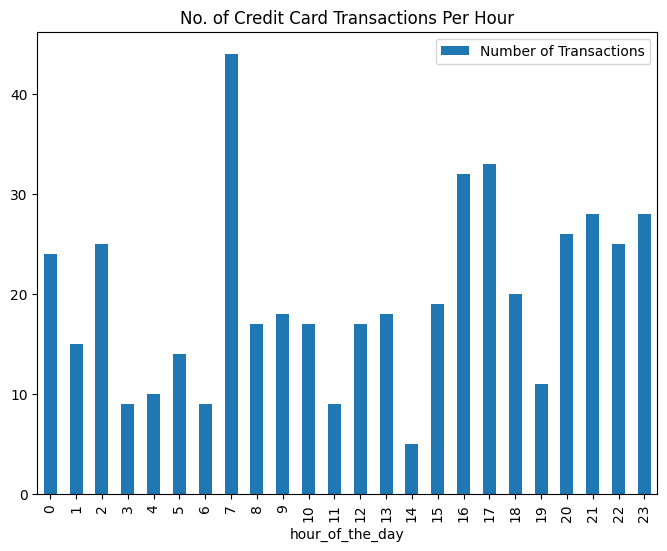

In [ ]:
plt.figure(figsize=(8,6))

# Transaction in hours
transactions = timeAnalysisgroupby[1].copy()

# Count of the Transactions
transactions.name = 'Number of Transactions'

# Plotting based on Transactions based on Hours
transactions.plot.bar(title="No. of Credit Card Transactions Per Hour", legend=True)

In [ ]:
timeAnalysisgroupby[0]

hour_of_the_day
0     16686
1     15920
2     17390
3     17237
4     12828
5      9403
6      5690
7      3045
8      4174
9      2499
10     2075
11     3452
12     5492
13     8542
14    13314
15    16323
16    16712
17    16389
18    14966
19    15801
20    16710
21    16039
22    16569
23    15997
Name: Amount, dtype: int64

In [ ]:
timeAnalysisgroupby[1]

hour_of_the_day
0     24
1     15
2     25
3      9
4     10
5     14
6      9
7     44
8     17
9     18
10    17
11     9
12    17
13    18
14     5
15    19
16    32
17    33
18    20
19    11
20    26
21    28
22    25
23    28
Name: Amount, dtype: int64

In [ ]:
timeAnalysisgroupby

Class  hour_of_the_day
0      0                  16686
       1                  15920
       2                  17390
       3                  17237
       4                  12828
       5                   9403
       6                   5690
       7                   3045
       8                   4174
       9                   2499
       10                  2075
       11                  3452
       12                  5492
       13                  8542
       14                 13314
       15                 16323
       16                 16712
       17                 16389
       18                 14966
       19                 15801
       20                 16710
       21                 16039
       22                 16569
       23                 15997
1      0                     24
       1                     15
       2                     25
       3                      9
       4                     10
       5                     14
       6         

### Checking Valid Transactions 

<Axes: title={'center': 'Valid Transactions'}, ylabel='Frequency'>

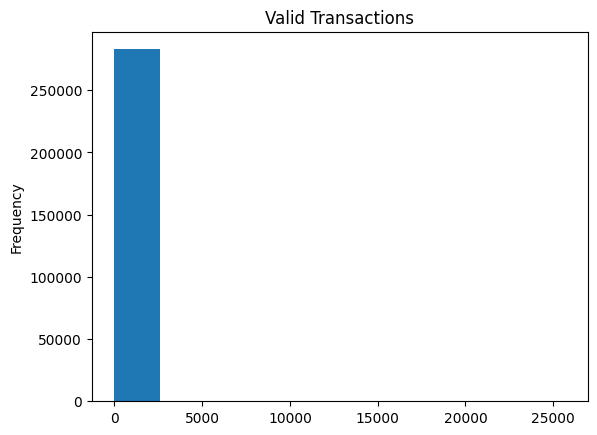

In [ ]:
timeAnalysis[timeAnalysis.Class == 0].Amount.plot.hist(title="Valid Transactions")

In [ ]:
timeAnalysis[timeAnalysis.Class == 0]

,Time,Amount,Class,datetime,hour_of_the_day
0,0.0,149.62,0,1970-01-01 05:30:00,5
1,0.0,2.69,0,1970-01-01 05:30:00,5
2,1.0,378.66,0,1970-01-01 05:30:01,5
3,1.0,123.50,0,1970-01-01 05:30:01,5
4,2.0,69.99,0,1970-01-01 05:30:02,5
...,...,...,...,...,...
284802,172786.0,0.77,0,1970-01-03 05:29:46,5
284803,172787.0,24.79,0,1970-01-03 05:29:47,5
284804,172788.0,67.88,0,1970-01-03 05:29:48,5
284805,172788.0,10.00,0,1970-01-03 05:29:48,5


In [ ]:
# Since Most of the Transactions falls b/w 0 to 2.5k, We will try to add Treshold.

<Axes: title={'center': 'Valid Transaction (Amount Lesser than 4000)'}, ylabel='Frequency'>

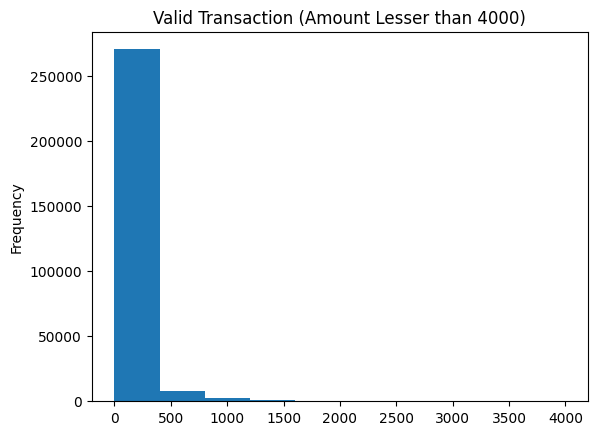

In [ ]:
timeAnalysis[(timeAnalysis.Class==0) & (timeAnalysis.Amount <= 4000)].Amount.plot.hist(title="Valid Transaction (Amount Lesser than 4000)")

### Checking Fradulent Transactions

<Axes: title={'center': 'Valid Transactions'}, ylabel='Frequency'>

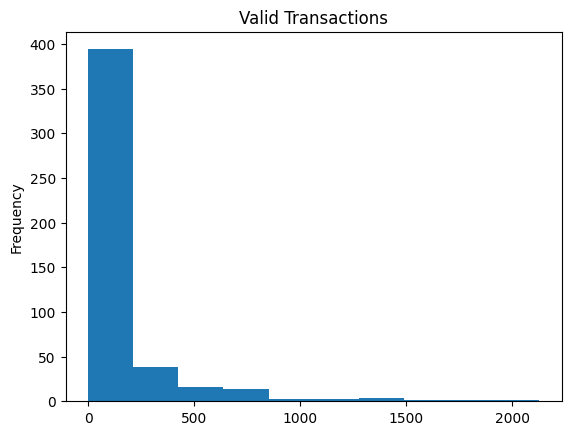

In [ ]:

timeAnalysis[timeAnalysis.Class == 1].Amount.plot.hist(title="Valid Transactions")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


##### **Class - Target Variable**
    - 0 - Legitimate
    - 1 - Fraud

##### **V1 - V28 - Anonymous Features (Applied PCA transformation for privacy)**

- Highly Imbalanced Dataset

### **Class Imbalance Analysis**

In [ ]:

df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [ ]:
df['Class'].value_counts(normalize=True) * 100


Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [ ]:
import seaborn as sns

Text(0.5, 1.0, 'Class Distribution')

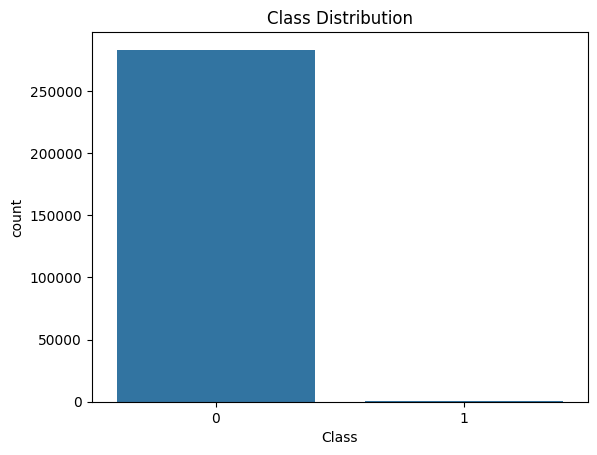

In [ ]:
sns.countplot(x='Class',data=df)
plt.title("Class Distribution")

#### Observation / Insights

- Fraud cases are typically lesser than 0.2%
- Severe imbalance in the dataset

### **Transaction Amount Analysis**

In [ ]:
df['Amount'].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

##### Understand Amount feature distribution

<Axes: xlabel='Amount', ylabel='Count'>

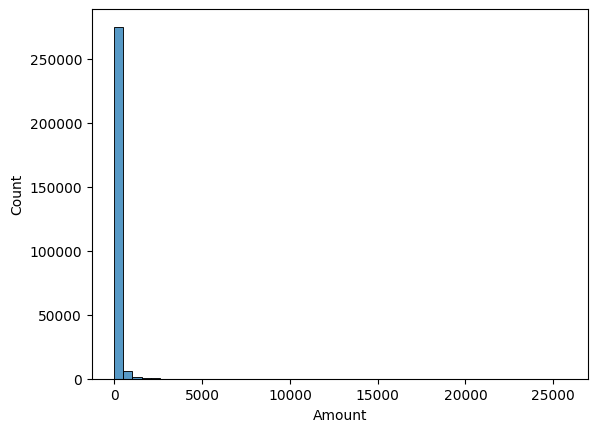

In [ ]:
sns.histplot(df['Amount'],bins=50)

##### Fraud VS Non Fraud

<Axes: xlabel='Class', ylabel='Amount'>

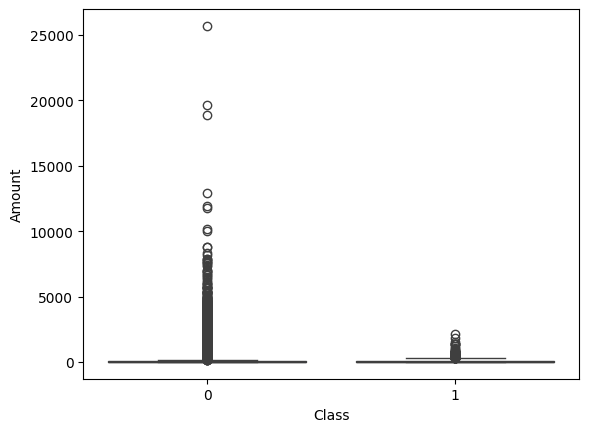

In [ ]:
sns.boxplot(x='Class',y='Amount',data=df)

#### Observation / Insights

- Fraud - 1 transactions often have lower median amounts
- Extreme Outliers

In [ ]:
df_0 = df[df['Class'] == 0]
df_1 = df[df['Class'] == 1]

In [ ]:
# Compare Distribution of 0 & 1

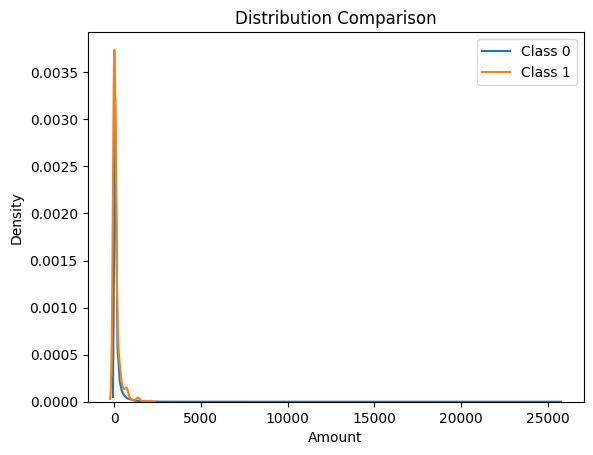

In [ ]:
sns.kdeplot(df_0['Amount'],label='Class 0')
sns.kdeplot(df_1['Amount'],label='Class 1')
plt.legend()
plt.title("Distribution Comparison")
plt.show()

### **Time Feature Analysis**

<Axes: xlabel='Time', ylabel='Count'>

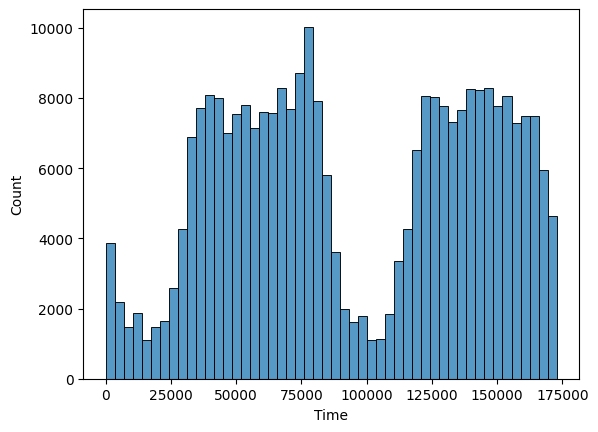

In [ ]:
sns.histplot(df['Time'],bins=50)

### **Correlation Analysis**

In [ ]:
corr = df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,0.031068,-0.248536,0.125500,-0.065958,-0.100316,-0.184392,0.011286,-0.073819,0.090305,0.029537,-0.051022,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,0.000815,0.001028,-0.001524,-0.000568,-0.002663,-0.000602,-0.003345,-0.003491,-0.003535,0.000919,-0.001393,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,0.000620,-0.000633,0.002266,0.000680,0.002711,0.001538,0.004013,0.003244,0.002477,-0.000358,-0.001287,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,-0.009632,0.002339,-0.005900,0.000113,-0.003027,-0.001230,-0.004430,-0.008159,-0.003495,-0.000016,-0.002269,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,0.002753,-0.001223,0.003366,0.000177,0.002801,0.000572,0.003346,0.003655,0.002325,-0.000560,0.000318,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,-0.006050,0.000411,-0.002342,0.000019,-0.001000,-0.001171,-0.002373,-0.004466,-0.002685,0.000436,-0.001185,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,-0.002180,-0.000211,-0.001185,0.000397,0.000184,-0.000470,0.000122,-0.001716,0.000541,0.000106,-0.000181,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,-0.013617,0.002454,-0.006153,-0.000170,-0.003816,-0.001394,-0.005944,-0.008794,-0.004279,0.000846,-0.001192,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,0.000481,0.004688,-0.004414,-0.001381,-0.008387,0.001044,-0.004376,-0.005576,-0.001323,-0.000626,0.000271,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,-0.012613,-0.000217,-0.002385,0.000745,0.001981,-0.000283,-0.000086,-0.002318,-0.000373,0.000247,-0.001838,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


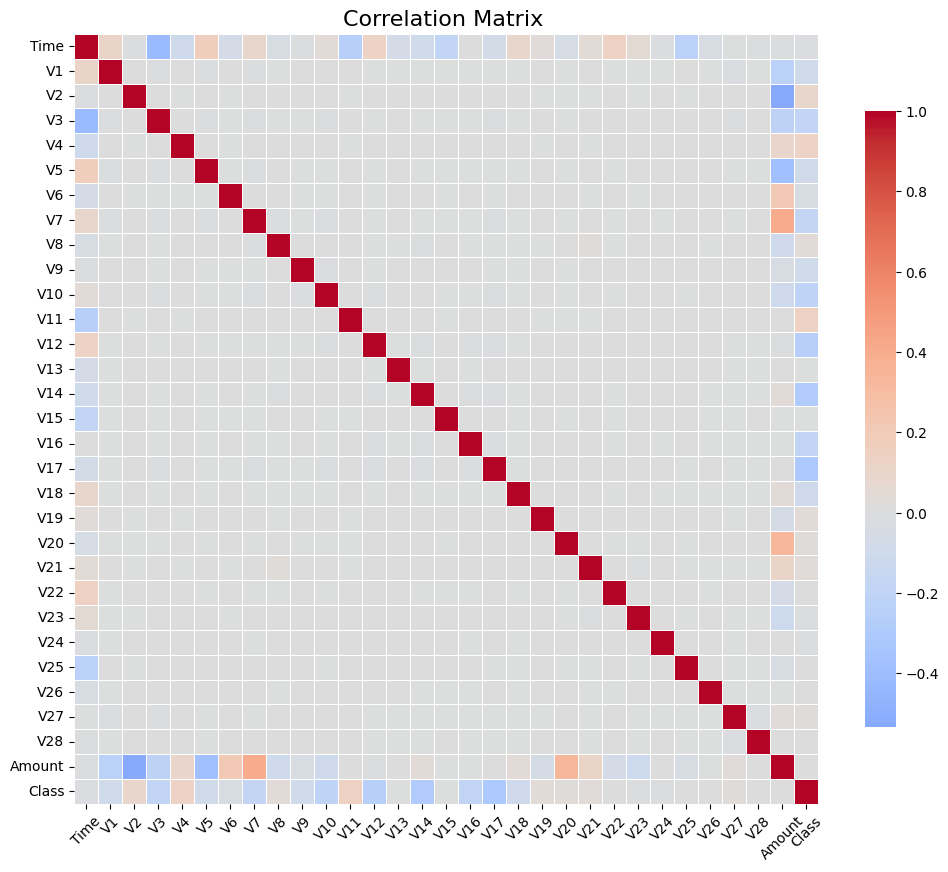

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm',center=0,annot=False,fmt=".1f",linewidths=0.5,cbar_kws={"shrink":0.8})
plt.title("Correlation Matrix ",fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

#### Observation / Insights

- Most of the PCA (V1 to V28) features have low correlations
- Some features show mild correlation with Class

### **Independent Feature vs Target Feature - Relationship**

In [ ]:
df.groupby('Class').mean().T

Class,0,1
Time,94835.058093,80450.513742
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197
V6,0.001251,-1.432518
V7,0.010447,-5.175912
V8,-0.002448,0.953255
V9,0.002613,-2.522124


In [ ]:
independent_features = df.columns[:-1]
independent_features

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

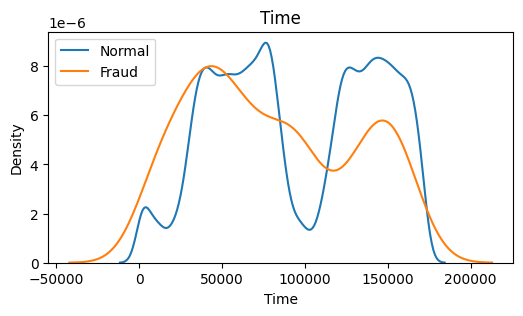

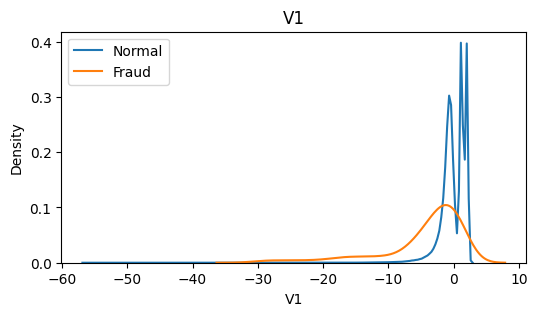

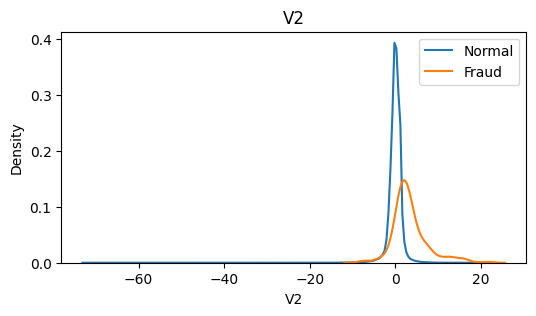

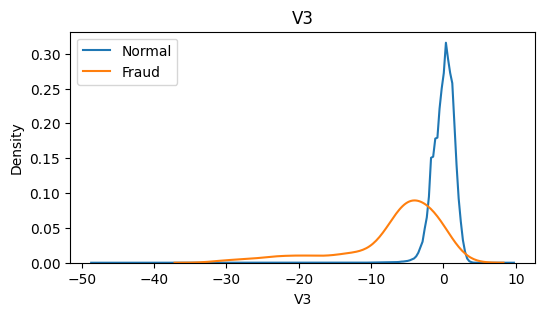

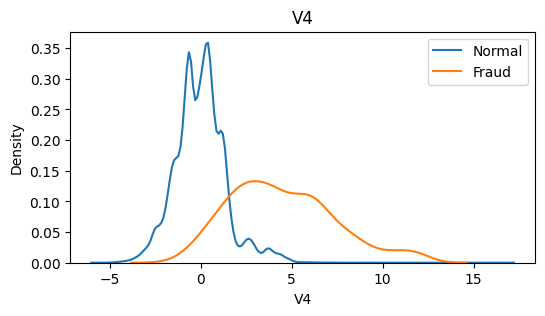

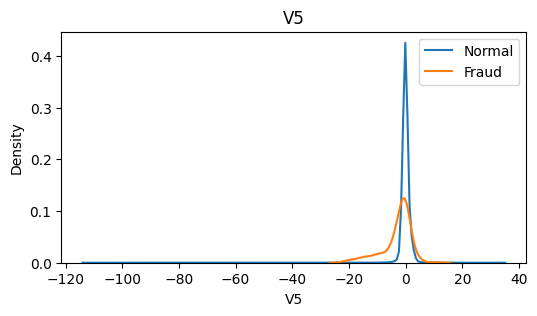

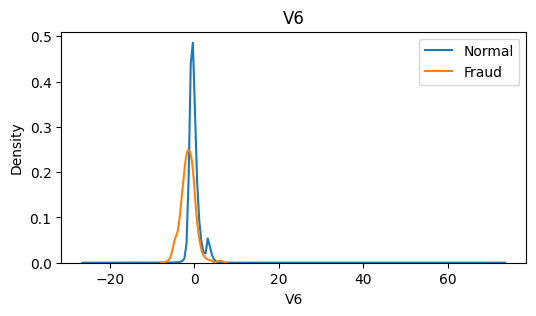

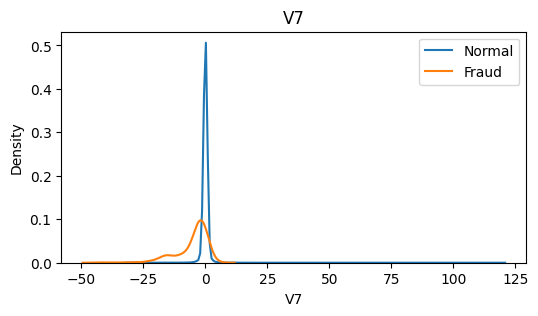

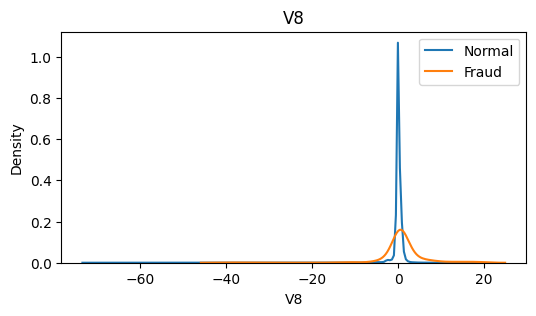

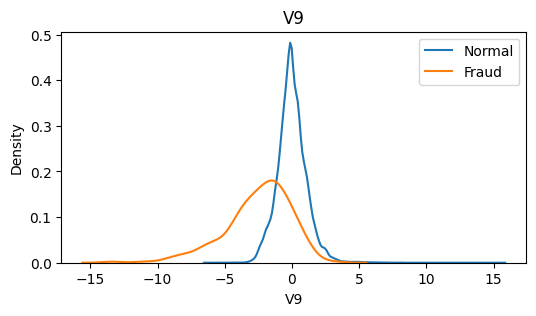

In [ ]:
for col in independent_features[:10]:
    plt.figure(figsize=(6,3))
    sns.kdeplot(df[df['Class']==0][col], label="Normal")
    sns.kdeplot(df[df['Class']==1][col],label="Fraud")
    plt.title(col)
    plt.legend()
    plt.show()

#### Assignment
- Extend the EDA